In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA

In [4]:
df = yf.download("TSLA", start="2015-01-01", end="2026-06-30")

tsla = df['Close'].dropna()

tsla.head()

[*********************100%***********************]  1 of 1 completed


Ticker,TSLA
Date,
2015-01-02,14.620667
2015-01-05,14.006000
2015-01-06,14.085333
2015-01-07,14.063333
2015-01-08,14.041333


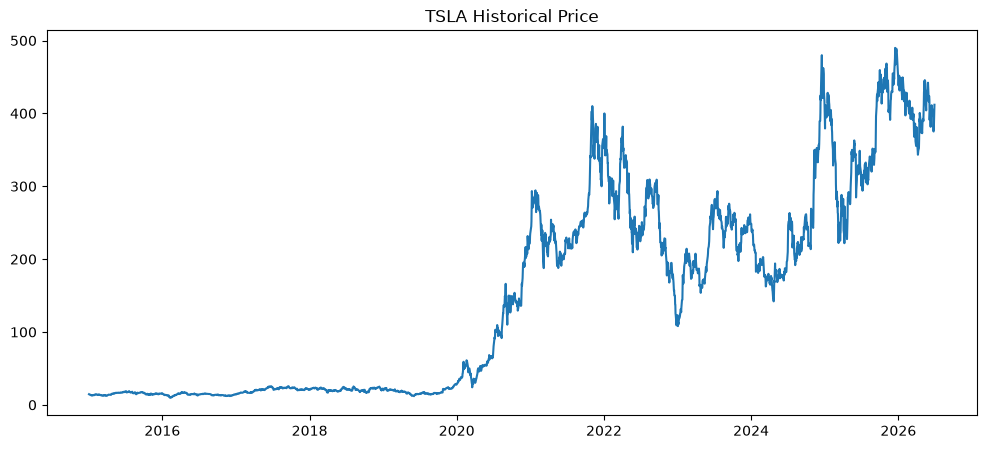

In [5]:
plt.figure(figsize=(12,5))
plt.plot(tsla)
plt.title("TSLA Historical Price")
plt.show()

In [6]:
train_size = int(len(tsla) * 0.8)

train = tsla[:train_size]
test = tsla[train_size:]

model = ARIMA(train, order=(0,1,0))
model_fit = model.fit()

c:\Users\Acer\Documents\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Acer\Documents\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Acer\Documents\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [7]:
future_forecast = model_fit.forecast(steps=180)
future_forecast = pd.Series(future_forecast)

c:\Users\Acer\Documents\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Acer\Documents\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [8]:
last_date = tsla.index[-1]
future_dates = pd.date_range(start=last_date, periods=181, freq='B')[1:]

future_forecast.index = future_dates

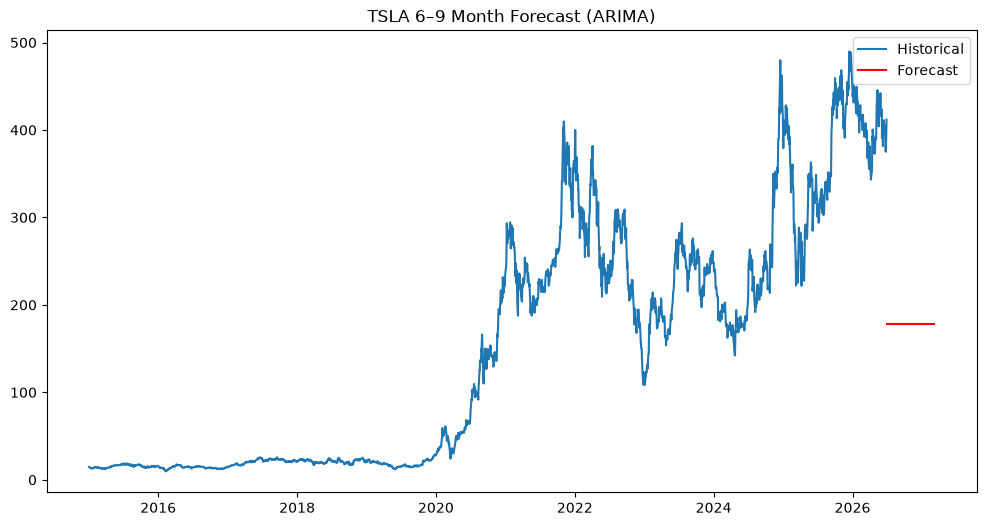

In [9]:
plt.figure(figsize=(12,6))

plt.plot(tsla, label="Historical")
plt.plot(future_forecast, label="Forecast", color="red")

plt.title("TSLA 6–9 Month Forecast (ARIMA)")
plt.legend()
plt.show()

## Trend Analysis

The forecast suggests that TSLA continues following its historical movement pattern, showing a continuation of the overall trend learned from past data.

However, the model is purely statistical and does not account for external market forces such as news, earnings reports, or macroeconomic events. This means the forecast represents a continuation of past behavior rather than a guaranteed future outcome.

As the forecast horizon increases, uncertainty naturally grows, making long-term predictions less reliable.

## Risks

- TSLA is highly volatile, which increases forecast uncertainty.
- ARIMA relies only on historical price patterns and ignores external factors.
- Unexpected market events can cause large deviations from predicted values.
- Long-term forecasts become less reliable due to compounding uncertainty.

## Opportunities

- The forecast provides a general directional view of TSLA price movement.
- It can support short- to medium-term investment planning.
- It helps identify potential trend continuation under normal market conditions.

## Final Insight

The ARIMA model is useful for capturing historical patterns and generating baseline forecasts, but it should not be used as a standalone decision-making tool. It works best when combined with other financial indicators and risk analysis methods.